In [2]:
import sys
sys.path.append("..")

In [ ]:
from securerag.models.fid import FiDT5

model_cls = FiDT5
model_path = "../models/nq_reader_base"
model: FiDT5 = model_cls.from_pretrained(model_path)


/root/miniconda3/envs/securerag/lib/python3.8/site-packages/transformers/modeling_utils.py:927: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(resolve

In [4]:
from securerag.models.rag_seq import RAGSequence


model_cls: RAGSequence = RAGSequence
checkpoint_path = "../models/rag-sequence-nq"
# retriever = transformers.RagRetriever.from_pretrained(
#     checkpoint_path, n_docs=self.config.n_context
# )
model: RAGSequence = model_cls.from_pretrained(checkpoint_path, n_docs=10)

In [5]:
print(model.state_dict)

<bound method Module.state_dict of RAGSequence(
  (rag): RagModel(
    (question_encoder): DPRQuestionEncoder(
      (question_encoder): DPREncoder(
        (bert_model): BertModel(
          (embeddings): BertEmbeddings(
            (word_embeddings): Embedding(30522, 768, padding_idx=0)
            (position_embeddings): Embedding(512, 768)
            (token_type_embeddings): Embedding(2, 768)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (encoder): BertEncoder(
            (layer): ModuleList(
              (0-11): 12 x BertLayer(
                (attention): BertAttention(
                  (self): BertSelfAttention(
                    (query): Linear(in_features=768, out_features=768, bias=True)
                    (key): Linear(in_features=768, out_features=768, bias=True)
                    (value): Linear(in_features=768, out_features=768, bias=True)
                  

In [6]:
import transformers
import torch
from securerag import data

path = "../data/open_domain_data/NQ/dev_with_scores.json"
datas = data.load(path=path, size=1000)
dataset = data.Dataset(data=datas, n_context=10)

tokenizer: transformers.T5Tokenizer = transformers.T5Tokenizer.from_pretrained(
    "../models/t5-base", return_dict=False
)
data_loader = torch.utils.data.dataloader.DataLoader(
    dataset=dataset,
    batch_size=10,
    collate_fn=data.FiDT5Collator(
        tokenizer=tokenizer,
        text_maxlength=50,
        answer_maxlength=50,
    ),
)
record1 = next(iter(data_loader))

/root/miniconda3/envs/securerag/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1767: FutureWarning: The `pad_to_max_length` argument is deprecated and will be removed in a future version, use `padding=True` or `padding='longest'` to pad to the longest sequence in the batch, or use `padding='max_length'` to pad to a max length. In this case, you can give a specific length with `max_length` (e.g. `max_length=45`) or leave max_length to None to pad to the maximal input size of the model (e.g. 512 for Bert).
  warnings.warn(
/root/miniconda3/envs/securerag/lib/python3.8/site-packages/transformers/tokenization_t5.py:184: UserWarning: This sequence already has </s>. In future versions this behavior may lead to duplicated eos tokens being added.
  warnings.warn(


In [7]:
(
    context_ids,
    context_masks
) = (
    record1.passage_ids,
    record1.passage_masks
)

In [8]:
import torch

total_params = sum(p.numel() for p in model.parameters())
print(f"总参数量: {total_params/1e6:.2f} M")


总参数量: 515.77 M


In [3]:
import torch
import torch.nn as nn
from transformers import T5Model, T5Config
from securerag.models.fid import FiDT5
import os
os.chdir("/root/Projects/SecureRAG")

model: FiDT5 = FiDT5.from_pretrained("models/nq_reader_base")
total_params = sum(p.numel() for p in model.parameters())
print(f"总参数量: {total_params/1e6:.2f} M")
def count_linear_parameters(model):
    total_params = 0
    # 遍历模型的每一层
    for name, module in model.named_modules():
        # 只统计线性层 (nn.Linear)
        # if isinstance(module, nn.Linear):
            # 获取该层的参数数量
        param_count = sum(p.numel() for p in module.parameters())
        total_params += param_count
        print(f"{name}: {param_count} parameters")
    return total_params

total_linear_params = count_linear_parameters(model)
print(f"Total Linear Parameters: {total_linear_params}")


/root/miniconda3/envs/securerag/lib/python3.8/site-packages/transformers/modeling_utils.py:927: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(resolve

总参数量: 222.90 M
: 222903936 parameters
shared: 24674304 parameters
encoder: 109628544 parameters
encoder.encoder: 109628544 parameters
encoder.encoder.block: 84953472 parameters
encoder.encoder.block.0: 7079808 parameters
encoder.encoder.block.0.module: 7079808 parameters
encoder.encoder.block.0.module.layer: 7079808 parameters
encoder.encoder.block.0.module.layer.0: 2360448 parameters
encoder.encoder.block.0.module.layer.0.SelfAttention: 2359680 parameters
encoder.encoder.block.0.module.layer.0.SelfAttention.q: 589824 parameters
encoder.encoder.block.0.module.layer.0.SelfAttention.k: 589824 parameters
encoder.encoder.block.0.module.layer.0.SelfAttention.v: 589824 parameters
encoder.encoder.block.0.module.layer.0.SelfAttention.o: 589824 parameters
encoder.encoder.block.0.module.layer.0.SelfAttention.relative_attention_bias: 384 parameters
encoder.encoder.block.0.module.layer.0.layer_norm: 768 parameters
encoder.encoder.block.0.module.layer.0.dropout: 0 parameters
encoder.encoder.block.0

In [7]:
state_dict = model.state_dict()

encoder_params = 0
decoder_params = 0
cross_attn_params = 0

for name, param in state_dict.items():
    if "shared" in name or "embed_tokens" in name:
        continue

    if name.startswith("encoder.encoder."):
        encoder_params += param.numel()

    elif name.startswith("decoder.block."):
        decoder_params += param.numel()

        if "EncDecAttention" in name:
            cross_attn_params += param.numel()

total_params = encoder_params + decoder_params

print(f"Encoder 参数: {encoder_params/1e6:.2f} M ({encoder_params/total_params:.2%})")
print(f"Decoder 参数: {decoder_params/1e6:.2f} M ({decoder_params/total_params:.2%})")
print(f"交叉注意力层参数: {cross_attn_params/1e6:.2f} M ({cross_attn_params/decoder_params:.2%} of Decoder)")

Encoder 参数: 84.95 M (42.86%)
Decoder 参数: 113.27 M (57.14%)
交叉注意力层参数: 28.31 M (24.99% of Decoder)


In [8]:
import torch.nn as nn
from thop import profile

class GenerateWrapper(nn.Module):
    def __init__(self, model, max_len):
        super().__init__()
        self.model = model
        self.max_len = max_len

    def forward(self, x, masks):
        return self.model.generate(x, masks, 50,)

wrapper = GenerateWrapper(model, max_len=20)

macs, params = profile(wrapper, inputs=(context_ids, context_masks))
print(macs, params)


NameError: name 'context_ids' is not defined

CPU 时间: 0.455631 秒
GPU CPU->GPU 时间: 0.090084 秒
GPU 计算时间: 0.048218 秒
GPU GPU->CPU 时间: 0.366367 秒
GPU 全流程时间: 0.504669 秒


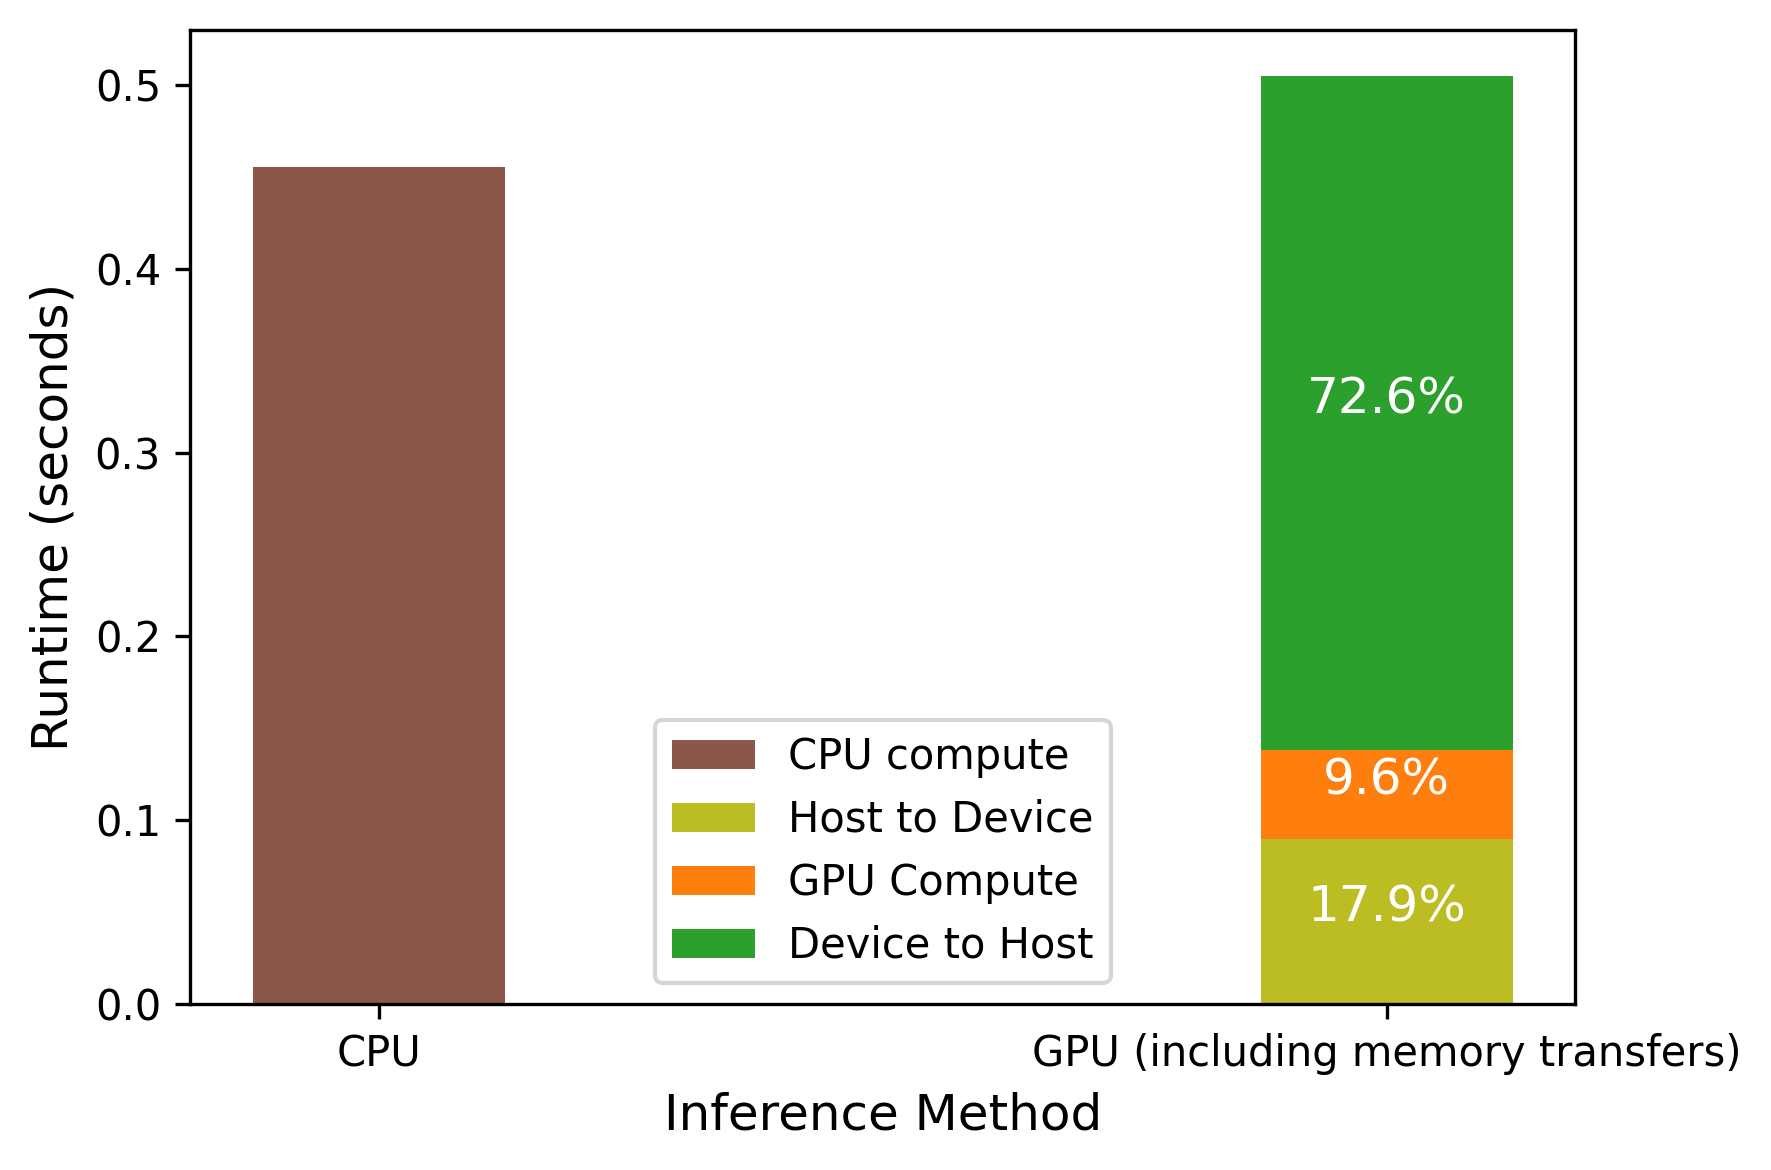

In [ ]:
import torch
import time

N = 768

# 生成 CPU 矩阵
A_cpu = torch.rand(64 * 10, 200, N, dtype=torch.float32)
B_cpu = torch.rand(N, N, dtype=torch.float32)

# CPU 计算时间
start = time.time()
C_cpu = torch.matmul(A_cpu, B_cpu)
cpu_time = time.time() - start
print(f"CPU 时间: {cpu_time:.6f} 秒")

# GPU 全流程拆解计时
# 1. CPU -> GPU
B_gpu = B_cpu.to("cuda")
torch.cuda.synchronize()
start = time.time()
A_gpu = A_cpu.to("cuda")
torch.cuda.synchronize()
cpu_to_gpu_time = time.time() - start

# 2. GPU 计算
torch.cuda.synchronize()
start = time.time()
C_gpu = torch.matmul(A_gpu, B_gpu)
torch.cuda.synchronize()
gpu_compute_time = time.time() - start

# 3. GPU -> CPU
torch.cuda.synchronize()
start = time.time()
C_result = C_gpu.to("cpu")
torch.cuda.synchronize()
gpu_to_cpu_time = time.time() - start

# 总流程时间
gpu_total_time = cpu_to_gpu_time + gpu_compute_time + gpu_to_cpu_time

print(f"GPU CPU->GPU 时间: {cpu_to_gpu_time:.6f} 秒")
print(f"GPU 计算时间: {gpu_compute_time:.6f} 秒")
print(f"GPU GPU->CPU 时间: {gpu_to_cpu_time:.6f} 秒")
print(f"GPU 全流程时间: {gpu_total_time:.6f} 秒")

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,4), dpi=300)

# ----- X positions -----
x = np.arange(2)  # 两个柱子：CPU only 和 GPU
width = 0.25

# ----- CPU baseline bar -----
plt.bar(x[0], cpu_time, width=width, color='tab:brown', label="CPU compute")

# ----- GPU stacked bar (H2D + compute + D2H) -----
colors = ['tab:olive', 'tab:orange', 'tab:green']  # H2D, Compute, D2H
gpu_values = [cpu_to_gpu_time, gpu_compute_time, gpu_to_cpu_time]
gpu_bottoms = [0, cpu_to_gpu_time, cpu_to_gpu_time + gpu_compute_time]
gpu_labels = ["Host to Device", "GPU Compute", "Device to Host"]

for val, bottom, color, label in zip(gpu_values, gpu_bottoms, colors, gpu_labels):
    plt.bar(x[1], val, bottom=bottom, width=width, color=color, label=label)
    # 标记百分比
    plt.text(x[1], bottom + val/2,
             f"{val/gpu_total_time*100:.1f}%", ha='center', fontsize=12, color='white')

# ----- X-axis labels -----
plt.xticks(x, ["CPU", "GPU (including memory transfers)"])

# ----- Labels and title -----
plt.ylabel("Runtime (seconds)", fontsize=12)
plt.xlabel("Inference Method", fontsize=12)
# plt.title("Inference Runtime Comparison", fontsize=13, pad=12)

# ----- Legend outside the plot to the right -----
plt.legend(fontsize=12, loc='lower center')

plt.tight_layout()
plt.show()


Warming up for N=768...
Warming up for N=1024...
Warming up for N=2048...


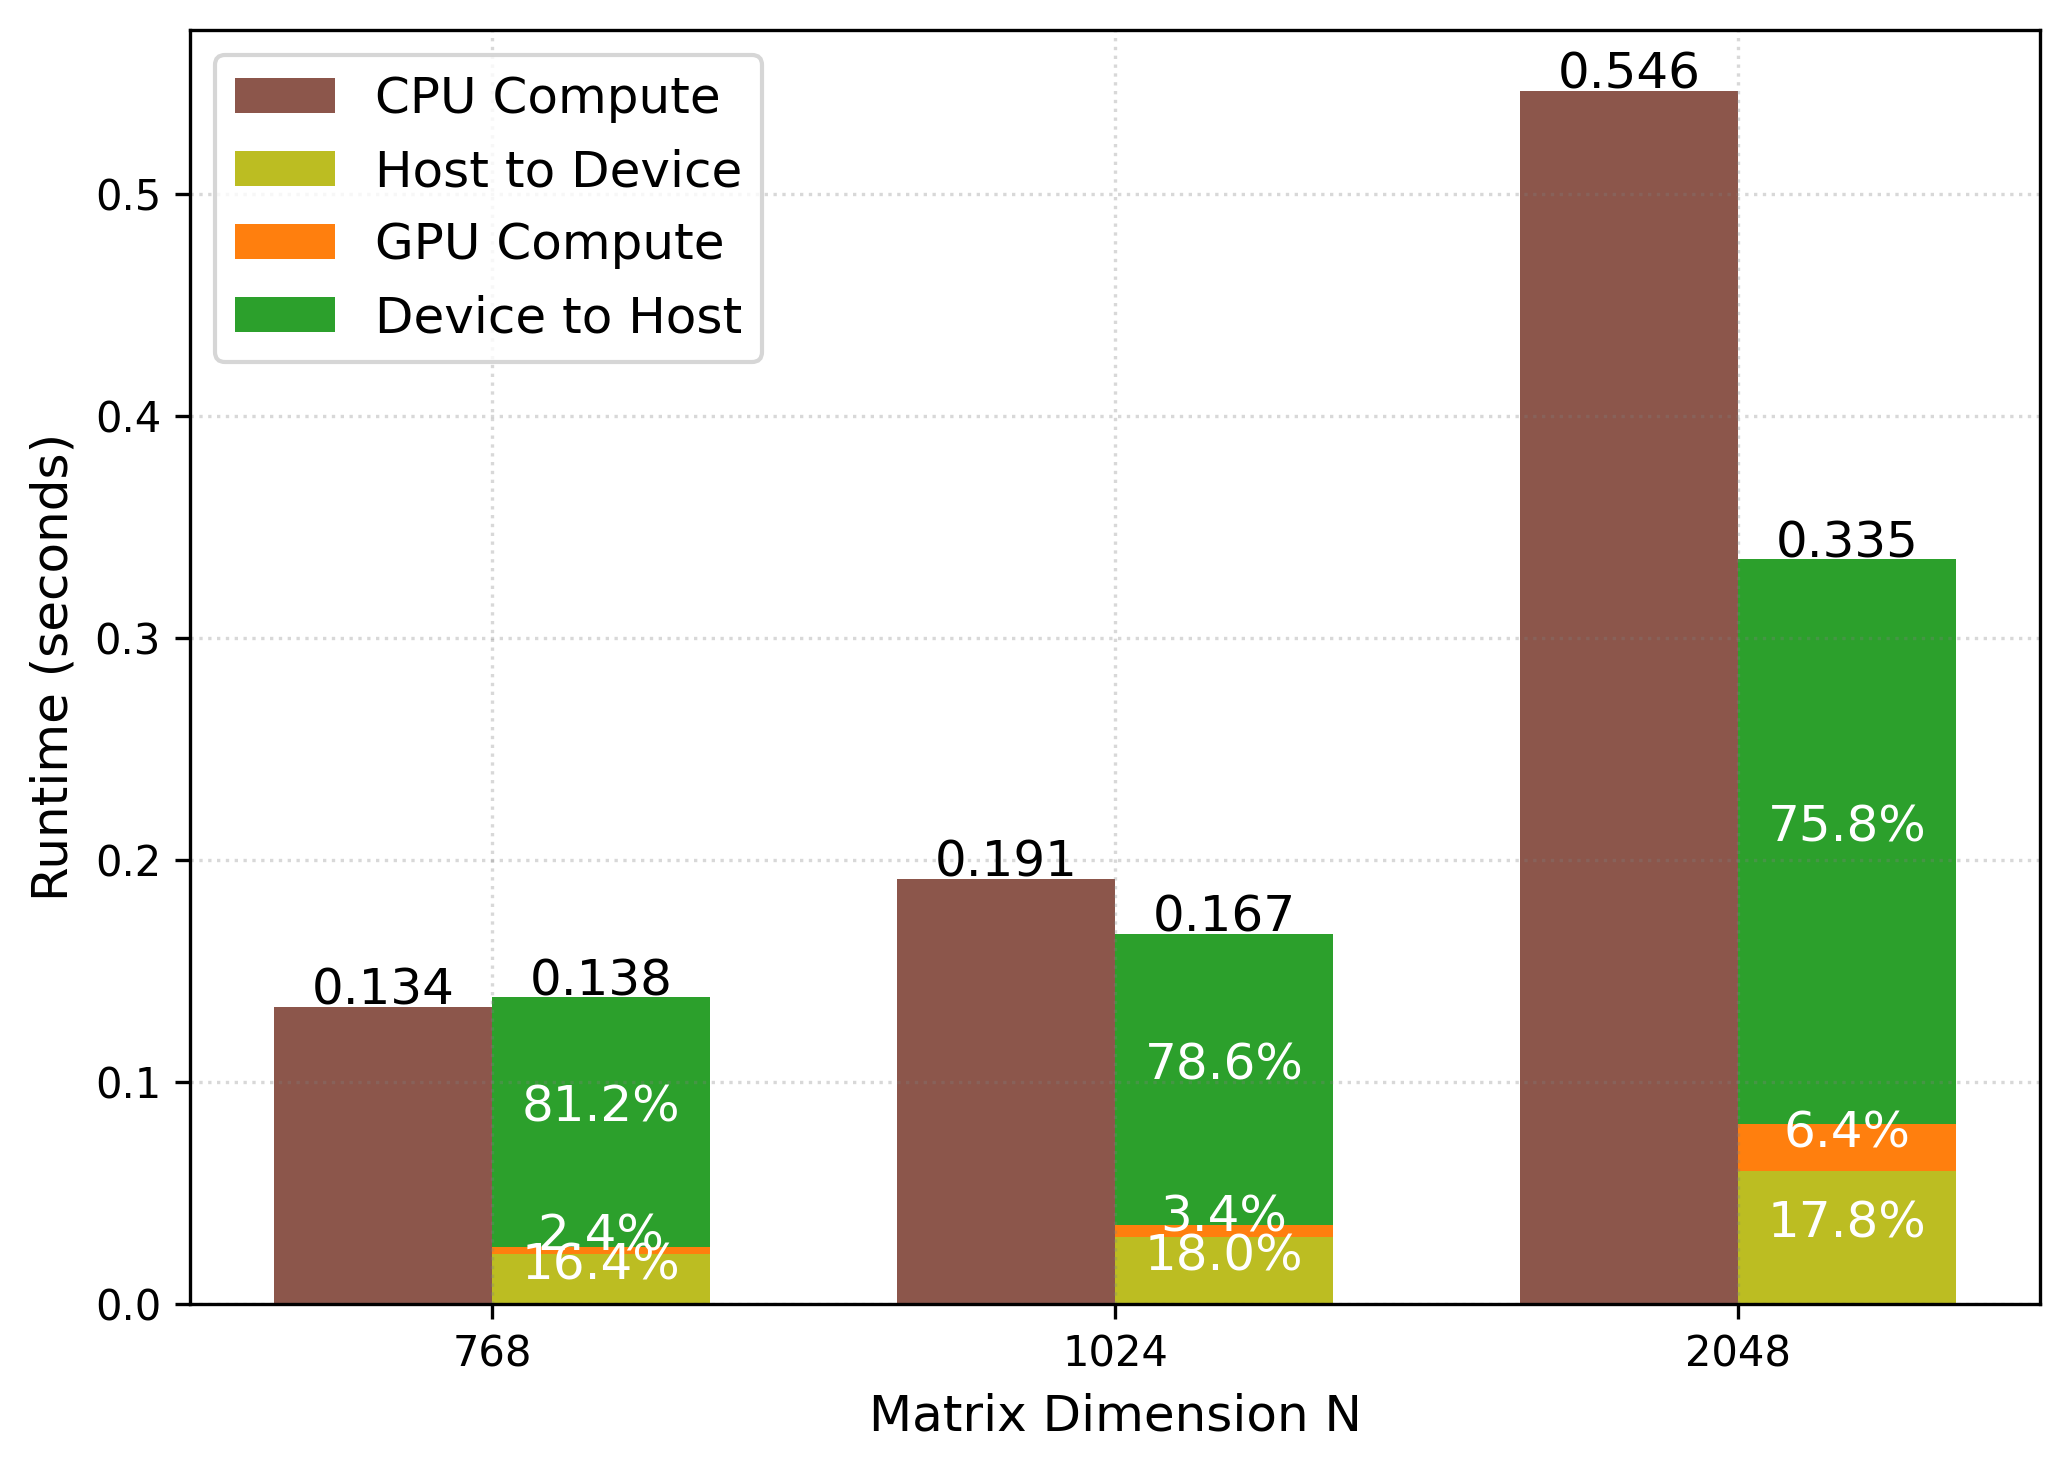

: 

In [ ]:
import torch # PyTorch for tensor operations
import time  # Wall-clock timing
import matplotlib.pyplot as plt
import numpy as np

# ----- Configuration and Data Collection -----
Ns = [768, 1024, 2048]
benchmark_results = []
WARMUP_RUNS = 5 # Number of runs to discard to ensure stability

for N in Ns:
    # ----- Data Setup (CPU) -----
    A_cpu = torch.rand(16 * 10, 200, N, dtype=torch.float32)
    B_cpu = torch.rand(N, N, dtype=torch.float32)

    # ----- CPU Matmul Timing (No overhead concern, but still accurate) -----
    start = time.time()
    C_cpu = torch.matmul(A_cpu, B_cpu)
    cpu_time = time.time() - start

    # ----- GPU Warm-up Phase (Excluding Influence) -----
    # 1. Transfer B to GPU once (static matrix)
    B_gpu = B_cpu.to("cuda")

    # 2. Perform several dummy runs to trigger JIT compilation and context setup
    print(f"Warming up for N={N}...")
    for _ in range(WARMUP_RUNS):
        A_gpu_dummy = A_cpu.to("cuda") # H2D transfer
        C_gpu_dummy = torch.matmul(A_gpu_dummy, B_gpu) # Compute
        C_gpu_dummy.to("cpu") # D2H transfer
        torch.cuda.synchronize() # Wait for everything to finish

    # ----- GPU Matmul and Transfer Timing (Measuring steady-state) -----

    # Time H2D Transfer
    torch.cuda.synchronize()
    start = time.time()
    A_gpu = A_cpu.to("cuda") # Transfer A
    torch.cuda.synchronize()
    h2d_time = time.time() - start

    # Time GPU Compute
    torch.cuda.synchronize()
    start = time.time()
    C_gpu = torch.matmul(A_gpu, B_gpu)
    torch.cuda.synchronize()
    gpu_compute_time = time.time() - start

    # Time D2H Transfer
    torch.cuda.synchronize()
    start = time.time()
    C_result = C_gpu.to("cpu")
    torch.cuda.synchronize()
    d2h_time = time.time() - start

    gpu_total_time = h2d_time + gpu_compute_time + d2h_time

    # Store (CPU_Time, H2D, Compute, D2H, GPU_Total)
    benchmark_results.append((cpu_time, h2d_time, gpu_compute_time, d2h_time, gpu_total_time))

# --- PLOTTING (Remaining code is unchanged from the last styled version) ---
plt.figure(figsize=(7, 5), dpi=300)

# ----- X positions and bar width -----
x_indices = np.arange(len(Ns)) # Indices for N=768, 1024, 2048
width = 0.35
group_spacing = 0.5 # Space between N groups

# Positions for CPU bars (left) and GPU bars (right)
x_cpu = x_indices - width / 2
x_gpu = x_indices + width / 2

# ----- Bar Labels and Colors (Matching First Example Style) -----
gpu_colors = ['tab:olive', 'tab:orange', 'tab:green'] # H2D, Compute, D2H
gpu_labels = ["Host to Device", "GPU Compute", "Device to Host"]

# We use the list to track which legend items have been drawn
legend_handles = []
legend_labels = []

# ----- Plotting Loop for each N size -----
for i, N in enumerate(Ns):
    cpu_t, h2d_t, gpu_c, d2h_t, gpu_t = benchmark_results[i]
    current_x_gpu = x_gpu[i]

    # --- 1. CPU Bar ---
    # Draw only the first CPU bar to get the legend handle
    if i == 0:
        cpu_bar = plt.bar(x_cpu[i], cpu_t, width=width, color='tab:brown', label="CPU Compute")
        legend_handles.append(cpu_bar)
        legend_labels.append("CPU Compute")
    else:
        plt.bar(x_cpu[i], cpu_t, width=width, color='tab:brown')

    # Add text label for CPU time
    plt.text(x_cpu[i], cpu_t + 0.001, f"{cpu_t:.3f}", ha='center', fontsize=12)

    # --- 2. GPU Stacked Bar ---
    gpu_values = [h2d_t, gpu_c, d2h_t]
    # Bottoms calculation must be cumulative
    gpu_bottoms = [0, h2d_t, h2d_t + gpu_c]

    for j, (val, bottom, color, label) in enumerate(zip(gpu_values, gpu_bottoms, gpu_colors, gpu_labels)):
        # Draw the bar segment
        bar_segment = plt.bar(current_x_gpu, val, bottom=bottom, width=width, color=color)

        # Draw the legend handle only on the first N (i=0)
        if i == 0:
            legend_handles.append(bar_segment)
            legend_labels.append(label)

        # Add percentage label to the segment
        plt.text(current_x_gpu, bottom + val / 2,
                 f"{val/gpu_t*100:.1f}%", ha='center', fontsize=12, color='white')

    # Add text label for GPU total time
    plt.text(current_x_gpu, gpu_t + 0.001, f"{gpu_t:.3f}", ha='center', fontsize=12)


# ----- X-axis labels -----
plt.xticks(x_indices, [str(N) for N in Ns])

# ----- Labels and title -----
plt.ylabel("Runtime (seconds)", fontsize=12)
plt.xlabel("Matrix Dimension N", fontsize=12)

# ----- Legend outside the plot to the right -----
plt.legend(legend_handles, legend_labels, fontsize=12, loc='upper left')
plt.grid(True, which="major", linestyle=":", color="gray", alpha=0.3)

plt.tight_layout()
plt.show()